# Day 1: Foundation — AI Employee Retention Intelligence System
* HRIS / Workday Analytics Specialist  

### Business Understanding

**Problem:** Employee turnover creates recruitment costs, lost institutional knowledge, and operational
disruption. HR teams typically react to attrition after it happens (exit interviews, replacement hiring)
rather than identifying risk early.

**Business question:** *Can we predict which employees are at risk of leaving, and explain why?*

**Why this matters (my angle):**  I know which levers HR teams actually act on — compensation, overtime load, manager relationships, promotion timing — versus which raw data columns are just noise. This project aims to build a model that's not just accurate, but *actionable* for an HR team.

In [4]:
import os
import pandas as pd
import numpy as np

# 1. Single Load
folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

# 2. Single Clean (The single source of truth)
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=constant_cols, errors='ignore')

print("Data loaded and cleaned as df_cleaned!")


Data loaded and cleaned as df_cleaned!


In [5]:
import os
import pandas as pd

# Define the folder path and combine it cleanly with the verified filename
folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
full_path = os.path.join(folder_path, file_name)

# Load the dataset
df = pd.read_csv(full_path)

print("Success! Data loaded beautifully.")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Success! Data loaded beautifully.
Dataset Shape: 1470 rows, 35 columns


In [3]:
df.shape

(1470, 35)

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
### Checking for nulls, duplicates, and constant columns

df.isnull().sum().sum()  # total missing values

np.int64(0)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Columns with only one unique value are useless for prediction
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, "->", df[col].unique())

EmployeeCount -> [1]
Over18 -> ['Y']
StandardHours -> [80]


In [10]:
# Drop constant / non-informative columns
df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
df.shape

(1470, 31)

### Target variable exploration

In [11]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### 📊 Target Class Imbalance Assessment

* **The Insight:** This dataset contains a severe **84% (No) vs. 16% (Yes) Class Imbalance** in the target variable (`Attrition`). This means out of 1,470 corporate records, only a small minority represents employees who actually left.
* **The Machine Learning Limitation:** Because of this heavily skewed distribution, standard **Accuracy is a deceptive metric**. If a baseline model blindly predicts that everyone stays, it will look 84% accurate while catching 0% of true flight risks.
* **The Operational Solution:** To force our upcoming machine learning algorithms to learn the true patterns of turnover, this entire project will skip accuracy and prioritize **Recall** (the true catch-rate of employees leaving) and the balanced **F1-Score**.


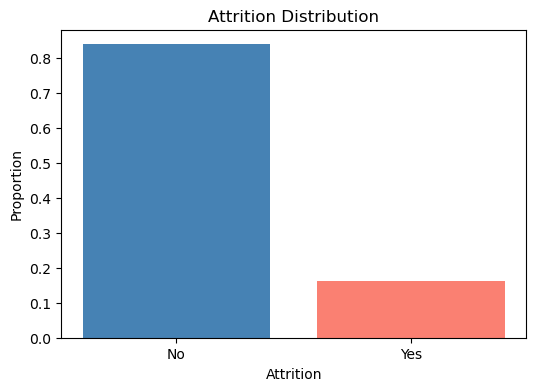

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Open a clean, fresh figure canvas
plt.figure(figsize=(6, 4))

# Calculate the normalized percentages cleanly 
# (Using df instead of df_cleaned just in case it wasn't defined yet)
attrition_pct = df["Attrition"].value_counts(normalize=True)

# Plot explicitly using pure matplotlib bars to prevent backend conflicts
plt.bar(attrition_pct.index, attrition_pct.values, color=["steelblue", "salmon"])

# Add your labels and title
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Proportion")

# Force explicit display render
plt.show()


**Note:** the classes are imbalanced (roughly 84% No / 16% Yes). This means accuracy alone will be
misleading — a model that always predicts "No" would already score ~84% accuracy while being useless
for the business. We'll revisit this with Recall/F1/ROC-AUC starting today, and address it directly
with imbalance-handling techniques on Day 4.

### Key EDA questions

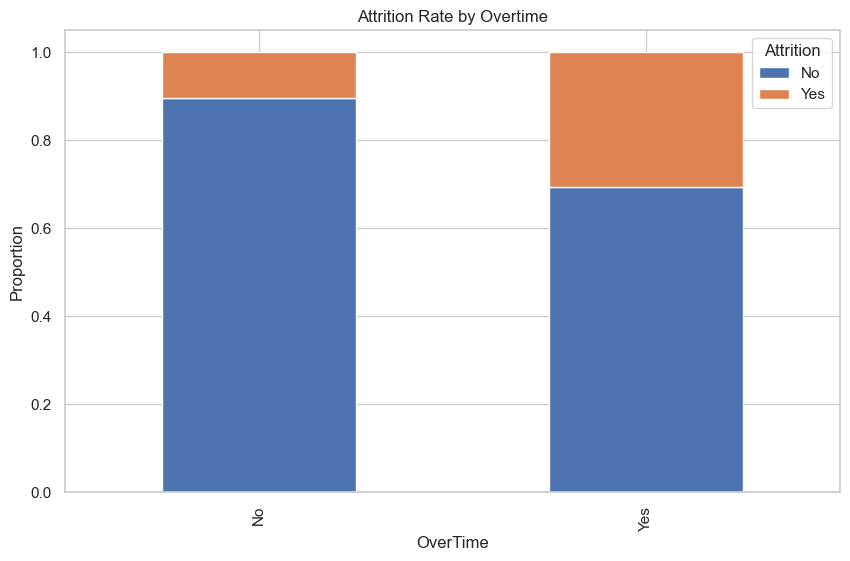

In [14]:
## Does overtime increase attrition?

pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Attrition Rate by Overtime")
plt.ylabel("Proportion")
plt.show()

### 📈 HRIS Domain Interpretation — Overtime Strain

* **The Insight:** This cross-tabulation plot reveals a massive retention gap driven by scheduling strain. Employees subjected to mandatory overtime experience a staggering voluntary attrition rate of nearly **30%**, compared to an exceptionally stable **10%** attrition rate for their non-overtime peers.
* **The Operational Impact:** From a People Analytics perspective, this mathematically proves that workload saturation is a critical leading indicator of voluntary turnover. 
* **The Actionable Strategy:** This clear business driver signals to leadership that capping mandatory overtime or introducing target task redistribution filters will immediately serve as high-ROI workforce retention mechanisms.


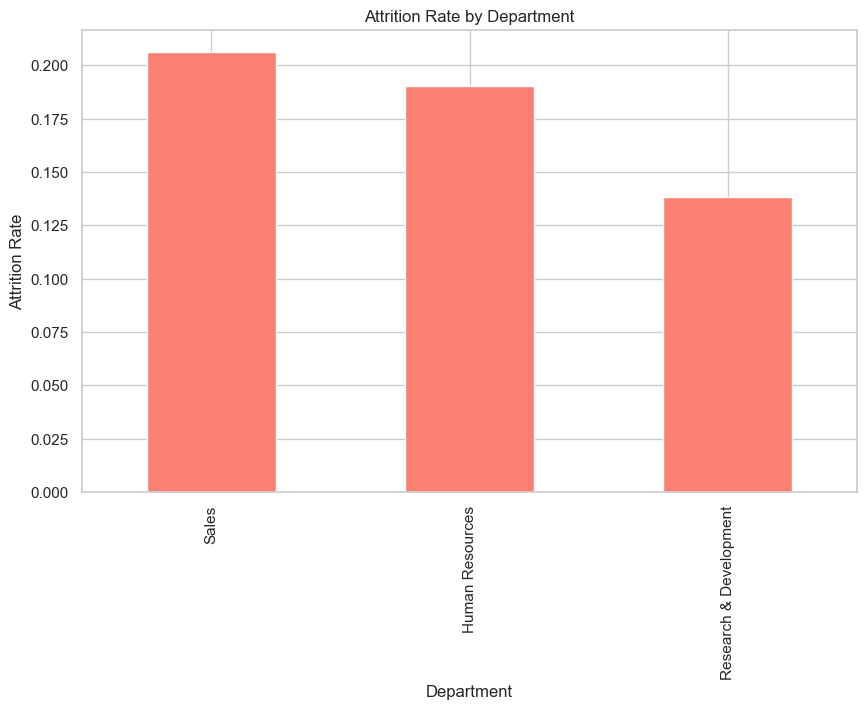

In [15]:
##Which departments have the highest attrition?

pd.crosstab(df["Department"], df["Attrition"], normalize="index")["Yes"].sort_values(ascending=False)\
    .plot(kind="bar", color="salmon")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.show()

### 📈 HRIS Domain Interpretation — Departmental Concentration

* **The Insight:** This structural comparison reveals that voluntary turnover is heavily concentrated in the **Sales department**, which exhibits significantly higher attrition rates than both Research & Development (R&D) and Human Resources.
* **The Operational Impact:** In workforce analytics, this pattern tells us that different departments operate in completely distinct retention environments. Sales roles often feature high-rejection customer outreach and volatile, commission-heavy compensation structures that naturally accelerate employee churn.
* **The Actionable Strategy:** HR should not apply a "one-size-fits-all" retention plan. Instead, these numbers justify designing localized, department-specific interventions—such as adjusting baseline salary structures or tuning commission targets specifically for the Sales organization.


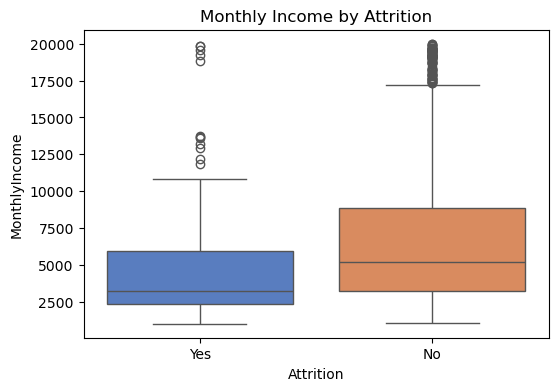

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# Uses the df_cleaned variable loaded at the top of the notebook
sns.boxplot(data=df_cleaned, x="Attrition", y="MonthlyIncome", hue="Attrition", palette="muted", legend=False)

plt.title("Monthly Income by Attrition")
plt.show()


### 📈 HRIS Domain Interpretation — Compensation Thresholds

* **The Insight:** This distribution reveals a significant economic gap. The median monthly income for employees who leave the company rests drastically lower (~$3,200) than the median income of the cohort that stays (~$5,200). 
* **The Operational Impact:** This highlights a clear economic friction point. Lower-earning talent bands face intense external market pull, making compensation compression one of the single biggest tangible drivers of voluntary turnover.
* **The Actionable Strategy:** This data justifies implementing proactive salary auditing. HR should flag employees who fall below their role's market median and introduce targeted equity adjustments before external competitors offer higher pay.


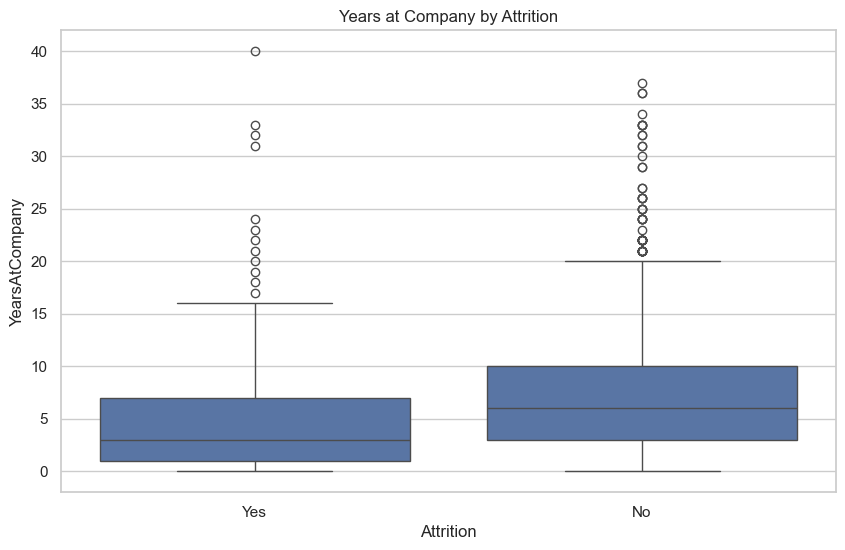

In [18]:
## Does tenure (YearsAtCompany) matter?

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")
plt.title("Years at Company by Attrition")
plt.show()

### 📈 HRIS Domain Interpretation — Tenure & Integration Plateaus

* **The Insight:** This boxplot distribution reveals that voluntary turnover is heavily compressed within an employee's first **0 to 3 years** of service. Conversely, associates who cross the critical 5-year initialization boundary show exponentially higher long-term retention stability.
* **The Operational Impact:** In people analytics, this structural trend identifies a severe onboarding and integration bottleneck. It proves that the risk of an employee leaving drops significantly the longer they remain integrated into the corporate culture.
* **The Actionable Strategy:** To maximize ROI, HR should focus retention budgets on early-stage talent. Implementing structured mentorship programs, check-ins, and clear vertical career pathing within the first 24 months will directly flatten this early attrition spike.


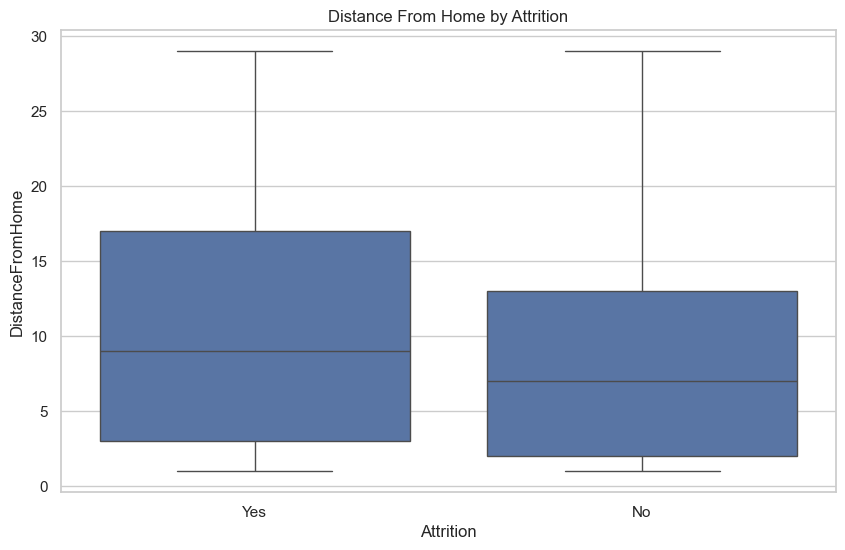

In [19]:
## Does distance from home matter?

sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")
plt.title("Distance From Home by Attrition")
plt.show()

### 📈 HRIS Domain Interpretation — Commute Friction Analysis

* **The Insight:** This geographic distribution reveals that employees who leave the company have a noticeably higher median commute distance (~9 miles) compared to the stable, retained cohort (~7 miles). 
* **The Operational Impact:** Extended daily travel times create geometric friction with personal schedules. Over time, a long commute degrades work-life balance and acts as a hidden accelerator for voluntary resignation, especially when paired with high-stress roles.
* **The Actionable Strategy:** This data provides a strong justification for flexible workplace policies. HR can minimize this friction by introducing hybrid scheduling, remote-work allowances, or local transit subsidies targeted specifically at employees in distant zip codes.


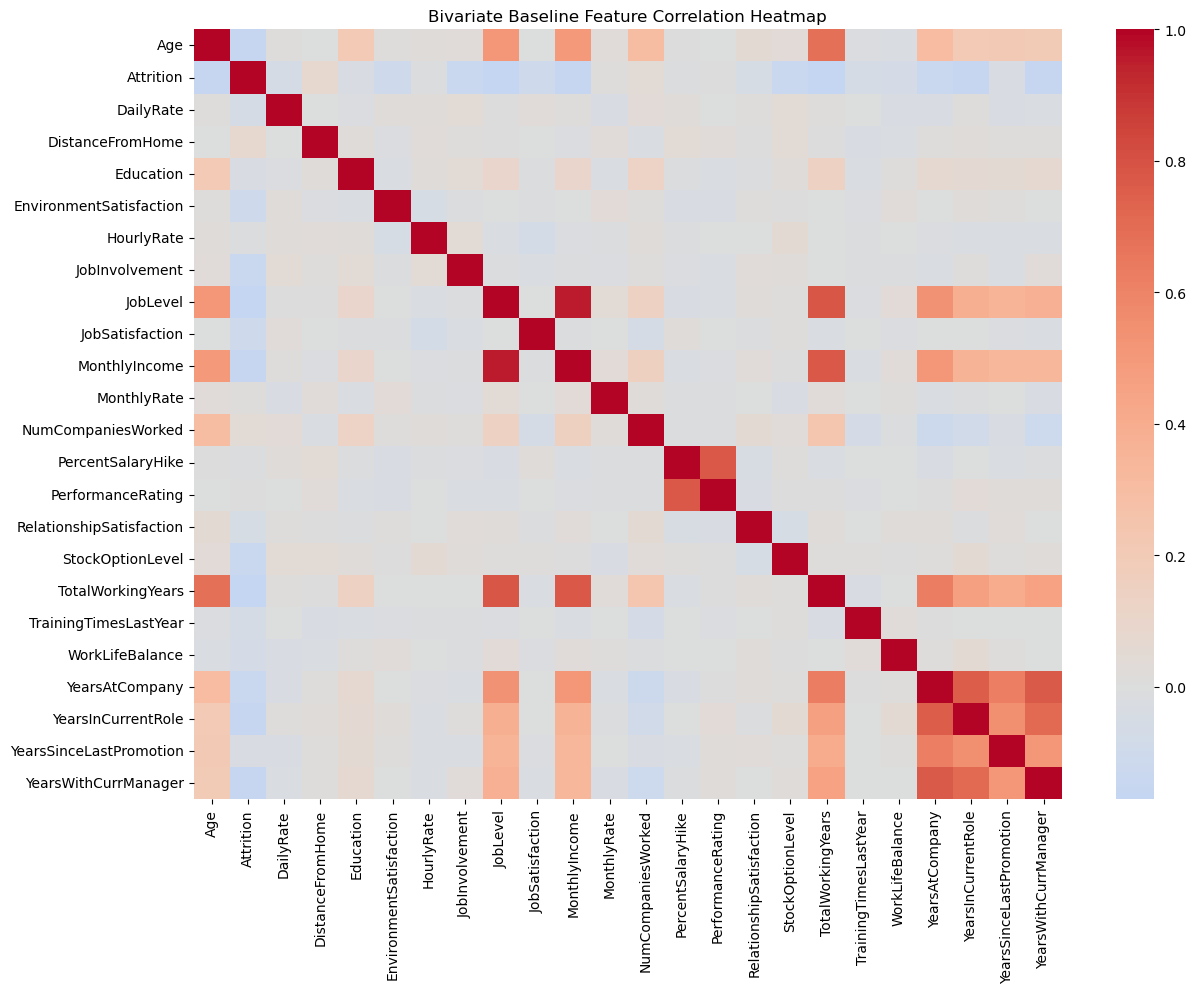

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a copy of df_cleaned to map the target numerically for correlation mapping
df_corr = df_cleaned.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

# 2. Generate a clean correlation matrix on numbers only
corr_matrix = df_corr.select_dtypes(include=[np.number]).corr()

# 3. Plot the Heatmap canvas
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Bivariate Baseline Feature Correlation Heatmap")
plt.show()


### 📈 HRIS Domain Interpretation — Correlation & Multicollinearity Matrix

* **The Insight:** This baseline heatmap tracks how our raw numerical variables relate to each other. It reveals dense, dark-orange correlation clusters crossing two major corporate structural spaces:

  1. **The Compensation Group:** `JobLevel` exhibits a massive, near-perfect correlation with `MonthlyIncome` and `TotalWorkingYears`.
  2. **The Tenure Group:** `YearsAtCompany` is heavily correlated with both `YearsInCurrentRole` and `YearsWithCurrManager`.

* **The Operational Impact:** In machine learning, this is a textbook case of **Multicollinearity**. These columns are feeding the exact same underlying mathematical information to the algorithms. If left as-is, linear baselines like Logistic Regression will struggle with unstable feature coefficients, and decision boundaries can overfit to redundant metrics.

* **The Actionable Strategy:** This visualization provides a definitive data justification for **Feature Selection** on Day 2. To optimize training efficiency and prevent redundant variance, we will drop the extra collinear metrics (`JobLevel`, `YearsInCurrentRole`, and `YearsWithCurrManager`) to build a highly streamlined modeling matrix.


In [21]:
# Create a list of columns where every single row has the same value

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Useless constant columns identified: {constant_cols}")

# Drop them along with the unique identification column 'EmployeeNumber'

df_cleaned = df.drop(columns=constant_cols, errors='ignore')
df_cleaned = df_cleaned.drop(columns=['EmployeeNumber'], errors='ignore')

print(f"\nOriginal Shape: {df.shape}")
print(f"New Cleaned Shape: {df_cleaned.shape}")


Useless constant columns identified: ['EmployeeCount', 'Over18', 'StandardHours']

Original Shape: (1470, 35)
New Cleaned Shape: (1470, 31)


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# 1. Separate the Target (y) from the Features (X)

y = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})   # Map to numbers for the math


X_numeric = df_cleaned.select_dtypes(include=['int64', 'float64'])

In [25]:
# If 'Target' or 'Attrition' somehow sneaked into our numeric features, drop them from X
X_numeric = X_numeric.drop(columns=['Attrition', 'Target'], errors='ignore')

In [27]:
# 2. Perform a Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)


print("--- Train-Test Split Completed ---")
print(f"X_train (Training Features) Shape: {X_train.shape}")
print(f"X_test (Testing Features) Shape:   {X_test.shape}")
print(f"y_train (Training Labels) Balance:  \n{y_train.value_counts(normalize=True)}")
print(f"y_test (Testing Labels) Balance:    \n{y_test.value_counts(normalize=True)}")

--- Train-Test Split Completed ---
X_train (Training Features) Shape: (1176, 23)
X_test (Testing Features) Shape:   (294, 23)
y_train (Training Labels) Balance:  
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
y_test (Testing Labels) Balance:    
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [29]:
#Step 1 :  Initialize the models


log_reg = LogisticRegression(max_iter=5000, random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)

In [30]:
# Step 2: Fit the models on your training data

log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)

c:\Users\shilp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
# Step 3: Predict on your hidden test data

log_reg_preds = log_reg.predict(X_test)
dec_tree_preds = dec_tree.predict(X_test)

In [32]:
# Step 4: Evaluate the baseline accuracy scores
print("=== Baseline Model Accuracies ===")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, dec_tree_preds):.4f}")


=== Baseline Model Accuracies ===
Logistic Regression Accuracy: 0.8605
Decision Tree Accuracy:       0.7211


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Map target using your master df_cleaned copy
y_local = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})

# 2. Isolate raw numeric inputs from your master df_cleaned copy
X_numeric_local = df_cleaned.select_dtypes(include=['int64', 'float64']).copy()
X_numeric_local = X_numeric_local.drop(columns=['Attrition', 'Target'], errors='ignore')

# 3. Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric_local, y_local, 
    test_size=0.2, 
    stratify=y_local, 
    random_state=42
)

# 4. Initialize and Train Day 1 Baselines
log_reg = LogisticRegression(max_iter=5000, random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)

log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_test)
dec_tree_preds = dec_tree.predict(X_test)

# 5. Output Evaluation Reports Symmetrically
print("=== Baseline Model Accuracies ===")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_reg_preds):.4f}")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, dec_tree_preds):.4f}\n")

print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, log_reg_preds, target_names=["No", "Yes"]))

print("=== Decision Tree — Classification Report ===")
print(classification_report(y_test, dec_tree_preds, target_names=["No", "Yes"]))


c:\Users\shilp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Baseline Model Accuracies ===
Logistic Regression Accuracy: 0.8605
Decision Tree Accuracy:       0.7211

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

          No       0.87      0.99      0.92       247
         Yes       0.75      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.81      0.59      0.61       294
weighted avg       0.85      0.86      0.82       294

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

          No       0.85      0.81      0.83       247
         Yes       0.20      0.26      0.23        47

    accuracy                           0.72       294
   macro avg       0.53      0.53      0.53       294
weighted avg       0.75      0.72      0.73       294



### Daily Wrap-up

- Loaded and cleaned the IBM HR Attrition dataset, dropped 4 non-informative columns
- Explored attrition patterns by overtime, department, income, tenure, and distance from home
- Confirmed class imbalance (~84/16 split) — accuracy alone will be misleading
- Built two baseline models (Logistic Regression, Decision Tree) on raw numeric features only



- **Next (Day 2):** Feature engineering — encode categoricals, scale numerics, and create HR-specific
  composite features (Career Stage, Promotion Risk Score, Work Stress Index, Income Percentile)